In [1]:
# PASO 1: IMPORTAR Y CARGAR DATOS

# 1. Importación de librerias
import pandas as pd
import numpy as np
import os

# 2. Configuración visual, para que se muestren todas las columnas sin importar el tamaño de la tabla
pd.set_option('display.max_columns', None)

# 3. Carga del Dataset
try:
    # Lectura del archivo CSV del dataset de inpescciones a restaurantes
    df_seguridad = pd.read_csv('../../datos/crudos/seguridad/NYPD_Complaint_Data_Current_(Year_To_Date)_MANHATHAN.csv')
    
    print("DIMENSIONES DEL DATASET")     
    #Visualización de la cantidad de filas y columnas del dataset
    print(f"📊 Dimensiones {df_seguridad.shape[0]:,} filas y {df_seguridad.shape[1]} columnas.")
    
    # Vista Previa de las primeras 5 filas
    print("\n--- VISUALIZACIÓN DEL CONTENIDO DEL DATASET ---")
    display(df_seguridad.head(5))
    
    # Información de las variables del dataset y su tipo de datos
    print("\n--- INFORMACIÓN DE VARIABLES ---")
    
    # Verificación de celdas y columnas vacias
    df_seguridad.info()

except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo.")

DIMENSIONES DEL DATASET
📊 Dimensiones 438,556 filas y 36 columnas.

--- VISUALIZACIÓN DEL CONTENIDO DEL DATASET ---


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PARKS_NM,PATROL_BORO,PD_CD,PD_DESC,PREM_TYP_DESC,RPT_DT,STATION_NAME,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,298788022,81,BROOKLYN,01/02/2025,01:50:00,01/02/2025,03:00:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,104,FELONY,FRONT OF,RAPE,(null),PATROL BORO BKLYN NORTH,159.0,"RAPE 1,ATTEMPT",STREET,01/02/2025,(null),<18,BLACK,M,NaN,18-24,WHITE,F,1005319,190473,"40,68946429526","-73,92402908995","(40.6894642952604, -73.9240290899499)",POINT (-73.9240290899499 40.6894642952604)
1,303250435,13,MANHATTAN,03/20/2025,00:30:00,NaN,(null),COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,104,FELONY,INSIDE,RAPE,(null),PATROL BORO MAN SOUTH,157.0,RAPE 1,HOSPITAL,03/20/2025,(null),UNKNOWN,BLACK,M,NaN,25-44,WHITE,M,988886,207857,"40,73720309857","-73,98327259815","(40.7372030985741, -73.9832725981497)",POINT (-73.9832725981497 40.7372030985741)
2,299744592,121,STATEN ISLAND,01/20/2025,18:30:00,01/20/2025,18:35:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,109,FELONY,INSIDE,GRAND LARCENY,(null),PATROL BORO STATEN ISLAND,433.0,"LARCENY,GRAND FROM STORE-SHOPL",DEPARTMENT STORE,01/20/2025,(null),UNKNOWN,BLACK HISPANIC,M,NaN,UNKNOWN,UNKNOWN,D,938881,167697,"40,626859","-74,16344","(40.626859, -74.16344)",POINT (-74.16344 40.626859)
3,307271594,47,BRONX,03/05/2025,17:00:00,NaN,(null),COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,104,FELONY,INSIDE,RAPE,(null),PATROL BORO BRONX,157.0,RAPE 1,RESIDENCE-HOUSE,05/30/2025,(null),25-44,BLACK,M,NaN,25-44,BLACK,F,1026480,262584,"40,88731363447","-73,84727175776","(40.8873136344706, -73.8472717577564)",POINT (-73.8472717577564 40.8873136344706)
4,309137838,14,MANHATTAN,07/05/2025,18:00:00,07/05/2025,18:31:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,344,MISDEMEANOR,FRONT OF,ASSAULT 3 & RELATED OFFENSES,(null),PATROL BORO MAN SOUTH,101.0,ASSAULT 3,STREET,07/05/2025,(null),18-24,BLACK,M,NaN,18-24,BLACK,F,0,0,0,0,"(0.0, 0.0)",POINT (0 0)



--- INFORMACIÓN DE VARIABLES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438556 entries, 0 to 438555
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CMPLNT_NUM                438556 non-null  object 
 1   ADDR_PCT_CD               438556 non-null  int64  
 2   BORO_NM                   438556 non-null  object 
 3   CMPLNT_FR_DT              438556 non-null  object 
 4   CMPLNT_FR_TM              438556 non-null  object 
 5   CMPLNT_TO_DT              418228 non-null  object 
 6   CMPLNT_TO_TM              438556 non-null  object 
 7   CRM_ATPT_CPTD_CD          438556 non-null  object 
 8   HADEVELOPT                438556 non-null  object 
 9   HOUSING_PSA               27186 non-null   float64
 10  JURISDICTION_CODE         438556 non-null  int64  
 11  JURIS_DESC                438556 non-null  object 
 12  KY_CD                     438556 non-null  int64  
 13  LAW_CAT_CD

In [2]:
# PASO 2: SELECCIÓN Y LIMPIEZA DE COLUMNAS

# 1. Selección de las variables (columnas) importantes para el proyecto
lista_columnas_seguridad = [
    'BORO_NM',           # Nombre del distrito (Manhattan)
    'CMPLNT_FR_DT',      # Fecha del incidente
    'CMPLNT_FR_TM',      # Hora del incidente
    'CMPLNT_NUM',        # ID único de la denuncia
    'Latitude',          # Coordenada Latitud
    'LAW_CAT_CD',        # Nivel de gravedad
    'Longitude',         # Coordenada Longitud
    'OFNS_DESC',         # Descripción del delito
    'PREM_TYP_DESC',     # Tipo de lugar del incidente
]

try:
    # 2. Creación del dataset de las columnas seleccionadas
    df_seguridad_limpio = df_seguridad[lista_columnas_seguridad].copy()

    # 3. Renombre de las columnas seleccionadas
    df_seguridad_limpio = df_seguridad_limpio.rename(columns={
        'BORO_NM': 'ZONA',
        'CMPLNT_FR_DT': 'FECHA',
        'CMPLNT_FR_TM': 'HORA',
        'CMPLNT_NUM': 'ID_QUEJA',
        'Latitude': 'LATITUD',
        'LAW_CAT_CD': 'GRAVEDAD',
        'Longitude': 'LONGITUD',
        'OFNS_DESC': 'DELITO',
        'PREM_TYP_DESC': 'TIPO_LUGAR',
    })

    # 4. Filtramos en ZONA el area de estudio ZONA="MANHATTAN"
    df_seguridad_limpio['ZONA'] = df_seguridad_limpio['ZONA'].str.upper() # estandarizacion a mayuscula
    df_seguridad_limpio = df_seguridad_limpio[df_seguridad_limpio['ZONA'] == 'MANHATTAN']

    # 5. Visualización del resultado del filtro
    print("✅ ¡Transformación de seguridad completada!")
    print(f"📊 Nueva dimensión {df_seguridad_limpio.shape[0]:,} filas y {df_seguridad_limpio.shape[1]} columnas")

    print("\n--- VISUALIZACIÓN DE LA NUEVA TABLA DE SEGURIDAD ---")
    display(df_seguridad_limpio.head())

except KeyError as e:
    print("❌ ERROR DE ESCRITURA: Python no encuentra una columna en el dataset de seguridad.")
    print(f"El error está en: {e}")

✅ ¡Transformación de seguridad completada!
📊 Nueva dimensión 103,595 filas y 9 columnas

--- VISUALIZACIÓN DE LA NUEVA TABLA DE SEGURIDAD ---


,ZONA,FECHA,HORA,ID_QUEJA,LATITUD,GRAVEDAD,LONGITUD,DELITO,TIPO_LUGAR
1,MANHATTAN,03/20/2025,00:30:00,303250435,"40,73720309857",FELONY,"-73,98327259815",RAPE,HOSPITAL
4,MANHATTAN,07/05/2025,18:00:00,309137838,0,MISDEMEANOR,0,ASSAULT 3 & RELATED OFFENSES,STREET
5,MANHATTAN,05/22/2025,14:30:00,306868358,0,MISDEMEANOR,0,ASSAULT 3 & RELATED OFFENSES,STREET
20,MANHATTAN,08/12/2025,12:30:00,311083105,0,FELONY,0,GRAND LARCENY,STREET
10575,MANHATTAN,10/04/2024,09:00:00,307086682,"40,706589",FELONY,"-74,015575",MISCELLANEOUS PENAL LAW,COMMERCIAL BUILDING


In [3]:
# PASO 3: ESTANDARIZACIÓN Y CONVERSIÓN DE TIPOS DE DATOS

# 1. FECHA Y HORA: Se convierten a formatos temporales
# Fecha
df_seguridad_limpio['FECHA'] = pd.to_datetime(df_seguridad_limpio['FECHA'], errors='coerce')

# Hora
df_seguridad_limpio['HORA'] = pd.to_datetime(df_seguridad_limpio['HORA'].astype(str), format='%H:%M:%S', errors='coerce').dt.time

# 2. NUMÉRICOS: Convertir Latitud y Longitud
cols_numericas = ['LATITUD', 'LONGITUD']

for col in cols_numericas:
    df_seguridad_limpio[col] = (df_seguridad_limpio[col].astype(str)
                               .str.replace(',', '.') # reemplazamos las coma por punto
                               .str.strip())

    df_seguridad_limpio[col] = pd.to_numeric(df_seguridad_limpio[col], errors='coerce') #coerce los erroes sean NaN


# 3. TEXTO: Asegurar que IDs y nombres sean texto (string)
cols_texto = ['ID_QUEJA', 'ZONA', 'DELITO', 'TIPO_LUGAR']
for col in cols_texto:
    if col in df_seguridad_limpio.columns:
        df_seguridad_limpio[col] = df_seguridad_limpio[col].astype(str).str.replace('.0', '', regex=False)


# 4. CATEGÓRICOS: La variable Gravedad convertida a categoria
df_seguridad_limpio['GRAVEDAD'] = df_seguridad_limpio['GRAVEDAD'].astype('category')


print("✅ ESTANDARIZACIÓN DEL TIPO DE DATO")
print("-" * 70)
print(df_seguridad_limpio.dtypes)
display(df_seguridad_limpio.head(5))

✅ ESTANDARIZACIÓN DEL TIPO DE DATO
----------------------------------------------------------------------
ZONA                  object
FECHA         datetime64[ns]
HORA                  object
ID_QUEJA              object
LATITUD              float64
GRAVEDAD            category
LONGITUD             float64
DELITO                object
TIPO_LUGAR            object
dtype: object


,ZONA,FECHA,HORA,ID_QUEJA,LATITUD,GRAVEDAD,LONGITUD,DELITO,TIPO_LUGAR
1,MANHATTAN,2025-03-20,00:30:00,303250435,40.737203,FELONY,-73.983273,RAPE,HOSPITAL
4,MANHATTAN,2025-07-05,18:00:00,309137838,0.000000,MISDEMEANOR,0.000000,ASSAULT 3 & RELATED OFFENSES,STREET
5,MANHATTAN,2025-05-22,14:30:00,306868358,0.000000,MISDEMEANOR,0.000000,ASSAULT 3 & RELATED OFFENSES,STREET
20,MANHATTAN,2025-08-12,12:30:00,311083105,0.000000,FELONY,0.000000,GRAND LARCENY,STREET
10575,MANHATTAN,2024-10-04,09:00:00,307086682,40.706589,FELONY,-74.015575,MISCELLANEOUS PENAL LAW,COMMERCIAL BUILDING


In [4]:
# PASO 4: ANÁLISIS DE LOS TIPOS DE INCIDENTES

# 1. Conteo de la cantidad de tipos de delitos existentes en el dataset
conteo_delitos = df_seguridad_limpio['DELITO'].value_counts()

print(f"📋 LISTADO COMPLETO DE TIPOS DE INCIDENTES: Tienes {len(conteo_delitos)} categorías de delitos diferentes.")
print("-" * 70)

print(conteo_delitos.to_string()) #to_string() mostrar toda la serie sin ocultar filas

# 3. Resumen de volumen total
print("-" * 70)
print(f"📊 Total de incidentes registrados en bruto: {df_seguridad_limpio.shape[0]:,}")

📋 LISTADO COMPLETO DE TIPOS DE INCIDENTES: Tienes 53 categorías de delitos diferentes.
----------------------------------------------------------------------
DELITO
PETIT LARCENY                       24681
HARRASSMENT 2                       12836
GRAND LARCENY                       12212
ASSAULT 3 & RELATED OFFENSES         9568
CRIMINAL MISCHIEF & RELATED OF       5709
DANGEROUS DRUGS                      4183
FELONY ASSAULT                       4060
OTHER OFFENSES RELATED TO THEFT      3722
OFF. AGNST PUB ORD SENSBLTY &        3001
VEHICLE AND TRAFFIC LAWS             2732
BURGLARY                             2572
ROBBERY                              2527
MISCELLANEOUS PENAL LAW              2267
FORGERY                              1924
OFFENSES AGAINST PUBLIC ADMINI       1769
DANGEROUS WEAPONS                    1584
SEX CRIMES                           1570
GRAND LARCENY OF MOTOR VEHICLE        931
CRIMINAL TRESPASS                     891
ADMINISTRATIVE CODE                  

In [5]:
# PASO 5: FILTROS POR GRAVEDAD

# 1. Filtramos la gravedad del incidente, solo se analizan los robos, incidentes graves y allanamientos
delitos_criticos = ['ROBBERY', 'FELONY ASSAULT', 'BURGLARY']

# 2. Aplicamos el filtro al dataset
df_seguridad_limpio = df_seguridad_limpio[df_seguridad_limpio['DELITO'].isin(delitos_criticos)].copy()

print("-" * 70)

# 3. Cantidad de registros por cada delito seleccionado
conteo_final = df_seguridad_limpio['DELITO'].value_counts()

print("📋 RESUMEN DE INCIDENTES CRÍTICOS EN MANHATTAN:")
print(conteo_final[conteo_final > 0].to_string())

# 4. Dimensión final por gravedad
print("-" * 70)
print(f"📊 Dataset listo para el análisis: {df_seguridad_limpio.shape[0]:,} incidentes críticos.")
print(f"📊 Nueva dimensión {df_seguridad_limpio.shape[0]:,} filas y {df_seguridad_limpio.shape[1]} columnas")

display(df_seguridad_limpio.head(5))

----------------------------------------------------------------------
📋 RESUMEN DE INCIDENTES CRÍTICOS EN MANHATTAN:
DELITO
FELONY ASSAULT    4060
BURGLARY          2572
ROBBERY           2527
----------------------------------------------------------------------
📊 Dataset listo para el análisis: 9,159 incidentes críticos.
📊 Nueva dimensión 9,159 filas y 9 columnas


,ZONA,FECHA,HORA,ID_QUEJA,LATITUD,GRAVEDAD,LONGITUD,DELITO,TIPO_LUGAR
11483,MANHATTAN,2025-04-05,01:20:00,304465601,40.704549,FELONY,-74.014290,FELONY ASSAULT,TRANSIT - NYC SUBWAY
13341,MANHATTAN,2025-08-29,21:30:00,312100053,40.705582,FELONY,-74.015405,ROBBERY,HOTEL/MOTEL
13720,MANHATTAN,2025-06-23,13:00:00,308510277,40.714542,FELONY,-74.015670,FELONY ASSAULT,STREET
13833,MANHATTAN,2025-08-28,15:35:00,312038981,40.710832,FELONY,-74.016085,FELONY ASSAULT,PARK/PLAYGROUND
14458,MANHATTAN,2025-02-21,07:42:00,301452054,40.705439,FELONY,-74.014685,ROBBERY,STREET


In [8]:
# PASO 6: ANÁLISIS DE DUPLICADOS

# 1. Verificación de duplicados basados en el ID de la Queja
duplicados = df_seguridad_limpio['ID_QUEJA'].duplicated().sum()
total_filas = df_seguridad_limpio.shape[0]

if duplicados > 0:
    print(f"⚠️ Se detectaron {duplicados:,} reportes repetidos. Procediendo a limpiar...")
    df_seguridad_limpio = df_seguridad_limpio.drop_duplicates(subset='ID_QUEJA', keep='first').copy()
else:
    print("✅ ¡EXCELENTE! No se encontraron registros duplicados en esta selección.")

# 2. Resultado del dataframe validado
print("-" * 70)
print(f"📈 Total de incidentes únicos para el análisis: {df_seguridad_limpio.shape[0]:,}")

✅ ¡EXCELENTE! No se encontraron registros duplicados en esta selección.
----------------------------------------------------------------------
📈 Total de incidentes únicos para el análisis: 9,159


In [10]:
# PASO 7: AUDITORIA DE CALIDAD DE LOS DATOS
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TRATAMIENTO DE "FALSOS NULOS": Convertimos todo texto que represente sin datos en NaN 
df_seguridad_limpio = df_seguridad_limpio.replace(['(null)', 'null', 'NULL', 'None'], np.nan)

# -------------------------------------------------------------------------
# 7.1. ANÁLISIS DE VALORES FALTANTES (NaN)
# -------------------------------------------------------------------------
print("\n🕳️ 1. VALORES FALTANTES (NaN):")
nulos = df_seguridad_limpio.isnull().sum()
nulos = nulos[nulos > 0] 

if not nulos.empty:
    porcentaje = (nulos / len(df_seguridad_limpio)) * 100
    reporte_nulos = pd.DataFrame({'Faltantes': nulos, '% Total': porcentaje.map('{:.2f}%'.format)})
    print(reporte_nulos.sort_values(by='Faltantes', ascending=False))
else:
    print("✅ No hay datos nulos en ninguna columna seleccionada.")

print("-" * 70)

# -------------------------------------------------------------------------
# 7.2. AUDITORÍA TEMPORAL (Distribución por Año y Mes)
# -------------------------------------------------------------------------
print("\n📅 2. ANÁLISIS TEMPORAL (Volumen por Año):")
# Analizamos la distribución para asegurar que no hay sesgos de un solo año
conteo_anios = df_seguridad_limpio['FECHA'].dt.year.value_counts().sort_index()
print(conteo_anios)

print("-" * 70)

# -------------------------------------------------------------------------
# 7.3. AUDITORÍA ESPACIAL (Coordenadas)
# -------------------------------------------------------------------------
print("\n🌍 3. ANÁLISIS ESPACIAL (Coordenadas):")

# Coordenadas que son NaN
sin_coords = df_seguridad_limpio['LATITUD'].isnull().sum()
# Coordenadas que son 0.0 (detectamos ceros en tu visualización anterior)
coords_cero = (df_seguridad_limpio['LATITUD'] == 0).sum()

print(f"-> Incidentes sin ubicación geográfica (NaN): {sin_coords:,}")
print(f"-> Incidentes con error de georeferencia (Lat=0): {coords_cero:,}")



🕳️ 1. VALORES FALTANTES (NaN):
            Faltantes % Total
TIPO_LUGAR         49   0.53%
----------------------------------------------------------------------

📅 2. ANÁLISIS TEMPORAL (Volumen por Año):
FECHA
2001       1
2010       1
2015       1
2017       1
2020       4
2022       2
2023      10
2024      81
2025    9058
Name: count, dtype: int64
----------------------------------------------------------------------

🌍 3. ANÁLISIS ESPACIAL (Coordenadas):
-> Incidentes sin ubicación geográfica (NaN): 0
-> Incidentes con error de georeferencia (Lat=0): 70


In [11]:
# PASO 8: GESTIÓN DE VALORES VACÍOS (NULLS)

import numpy as np

# 1. Verificación de valores nulls
print("📊 ESTADO ACTUAL DE VACÍOS:")
print(df_seguridad_limpio.isnull().sum())
print("-" * 70)

# 2. Limpieza de Valores nulls
# Copia del data frame
df_seguridad_final = df_seguridad_limpio.copy()

# A) Primera variable prioritaria (LATITUD y LONGITUD), sin coordenadas no podemos ubicar los incidentes 
filas_antes = df_seguridad_final.shape[0]
df_seguridad_final = df_seguridad_final.dropna(subset=['LATITUD', 'LONGITUD'])
df_seguridad_final = df_seguridad_final[df_seguridad_final['LATITUD'] != 0] #eliminamos las ubicaciones geograficas (0)

filas_borradas = filas_antes - df_seguridad_final.shape[0]
print(f"📍 Eliminados {filas_borradas} incidentes por falta de coordenadas exactas.")

# B) Variable de entorno (TIPO_LUGAR)
# Si no se especifica el lugar, lo etiquetamos como "No Especificado"
df_seguridad_final['TIPO_LUGAR'] = df_seguridad_final['TIPO_LUGAR'].fillna('No Especificado')
print(f"🏢 Variable TIPO_LUGAR completada con 'No Especificado'.")

print("-" * 70)

# 3. VISUALIZACIÓN DE RESULTADOS FINALES
print(f"📉 TOTAL FINAL DE INCIDENTES CRÍTICOS: {df_seguridad_final.shape[0]:,}")
print("Verificación final de nulos:")
print(df_seguridad_final.isnull().sum())

print("-" * 70)
display(df_seguridad_final.head(5))

📊 ESTADO ACTUAL DE VACÍOS:
ZONA           0
FECHA          0
HORA           0
ID_QUEJA       0
LATITUD        0
GRAVEDAD       0
LONGITUD       0
DELITO         0
TIPO_LUGAR    49
dtype: int64
----------------------------------------------------------------------
📍 Eliminados 70 incidentes por falta de coordenadas exactas.
🏢 Variable TIPO_LUGAR completada con 'No Especificado'.
----------------------------------------------------------------------
📉 TOTAL FINAL DE INCIDENTES CRÍTICOS: 9,089
Verificación final de nulos:
ZONA          0
FECHA         0
HORA          0
ID_QUEJA      0
LATITUD       0
GRAVEDAD      0
LONGITUD      0
DELITO        0
TIPO_LUGAR    0
dtype: int64
----------------------------------------------------------------------


,ZONA,FECHA,HORA,ID_QUEJA,LATITUD,GRAVEDAD,LONGITUD,DELITO,TIPO_LUGAR
11483,MANHATTAN,2025-04-05,01:20:00,304465601,40.704549,FELONY,-74.014290,FELONY ASSAULT,TRANSIT - NYC SUBWAY
13341,MANHATTAN,2025-08-29,21:30:00,312100053,40.705582,FELONY,-74.015405,ROBBERY,HOTEL/MOTEL
13720,MANHATTAN,2025-06-23,13:00:00,308510277,40.714542,FELONY,-74.015670,FELONY ASSAULT,STREET
13833,MANHATTAN,2025-08-28,15:35:00,312038981,40.710832,FELONY,-74.016085,FELONY ASSAULT,PARK/PLAYGROUND
14458,MANHATTAN,2025-02-21,07:42:00,301452054,40.705439,FELONY,-74.014685,ROBBERY,STREET


In [12]:
# PASO 9: FILTRO TEMPORAL

# 1. Filtro de Fecha: Seleccionamos exclusivamente el año 2025
filas_antes_temp = df_seguridad_final.shape[0]

# Aplicamos el filtro para mantener solo los registros del año 2025
df_seguridad_final = df_seguridad_final[df_seguridad_final['FECHA'].dt.year == 2025].copy()

filas_descartadas = filas_antes_temp - df_seguridad_final.shape[0]

print(f"📅 FILTRO TEMPORAL APLICADO: Solo año 2025")
print(f"-> Se descartaron {filas_descartadas:,} registros de años anteriores.")
print("-" * 70)
print(f"📊 Dimensión Final {df_seguridad_final.shape[0]:,} filas y {df_seguridad_final.shape[1]} columnas")

📅 FILTRO TEMPORAL APLICADO: Solo año 2025
-> Se descartaron 101 registros de años anteriores.
----------------------------------------------------------------------
📊 Dimensión Final 8,988 filas y 9 columnas


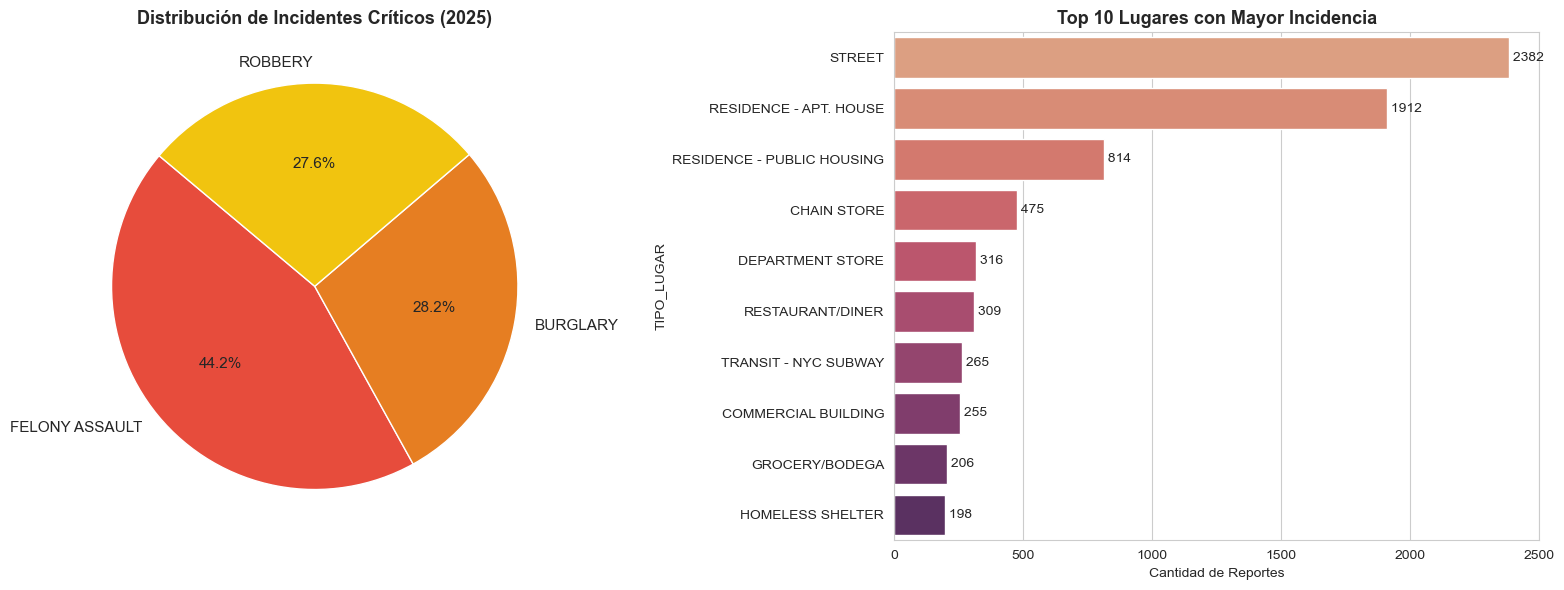

In [13]:
# PASO 10: ANÁLISIS EXPLORATORIO DE DATOS (EDA)

import matplotlib.pyplot as plt  #libreria para crear gráficos basicos
import seaborn as sns #libreria para mejorar es estilo y configuración de los gráficos

# Configuración de estilo y dimensiones
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  #tamaño del lienzo (ancho, alto)

# --- GRÁFICO 1: Pastel - Distribución de Delitos Críticos ---
plt.subplot(1, 2, 1) #configuración del gráfico
conteo_delitos = df_seguridad_final['DELITO'].value_counts()

# Colores segun la gravedad (tonos de rojo/naranja para peligro)
colores_pie = ['#e74c3c', '#e67e22', '#f1c40f'] 
plt.pie(conteo_delitos, labels=conteo_delitos.index, autopct='%1.1f%%', 
        startangle=140, colors=colores_pie, textprops={'fontsize': 11})
plt.title('Distribución de Incidentes Críticos (2025)', fontsize=13, fontweight='bold')

# --- GRÁFICO 2: Barras - Top 10 Lugares de Ocurrencia ---
plt.subplot(1, 2, 2) 

top_lugares = df_seguridad_final['TIPO_LUGAR'].value_counts().head(10)
grafico_barras = sns.barplot(x=top_lugares.values, y=top_lugares.index, 
                             hue=top_lugares.index, palette="flare", legend=False)
plt.title('Top 10 Lugares con Mayor Incidencia', fontsize=13, fontweight='bold')
plt.xlabel('Cantidad de Reportes')

# Etiquetas
for i in range(len(top_lugares)):
    plt.text(top_lugares.values[i], i, f' {top_lugares.values[i]}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# PASO 11: EXPORTACIÓN FINAL DEL DATASET
import os

# Definición del nombre del archivo y ruta para guardar
carpeta = '../../datos/limpios/seguridad'
nombre_archivo = '02_Seguridad_Manhattan.csv'
ruta_completa = os.path.join(carpeta, nombre_archivo)

try:
    # Guardamos el CSV
    # Usamos index=False para no guardar la columna de índices de pandas
    df_seguridad_final.to_csv(ruta_completa, index=False, encoding='utf-8-sig')
    
    print(f"\n💾 ¡EXPORTACIÓN EXITOSA!")
    print("-" * 70)
    print(f"📂 Archivo guardado en: {ruta_completa}")
    print(f"📊 Filas Exportadas: {df_seguridad_final.shape[0]:,}")

except Exception as e:
    print(f"❌ Error al guardar el archivo de seguridad: {e}")